
=== CartPole seed 0 ===


c:\Users\brygo\miniconda3\envs\rl-project\lib\site-packages\stable_baselines3\common\evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


1024 steps: 110.2 +/- 43.2
2048 steps: 130.8 +/- 49.4
3072 steps: 119.8 +/- 33.9
4096 steps: 98.8 +/- 24.1
5120 steps: 86.8 +/- 25.1
6144 steps: 101.8 +/- 23.3
7168 steps: 128.7 +/- 56.6
8192 steps: 130.9 +/- 38.8
9216 steps: 140.2 +/- 40.2
10240 steps: 218.1 +/- 111.9
11264 steps: 189.6 +/- 66.6
12288 steps: 196.1 +/- 68.1
13312 steps: 300.1 +/- 94.6
14336 steps: 259.4 +/- 89.6
>>> pi2 saved at 14336 steps: 259.4 +/- 89.6
15360 steps: 500.0 +/- 0.0
>>> pi1 saved at 15360 steps: 500.0 +/- 0.0
Both policies saved for seed 0, stopping
Suggested pi2_steps for the next run: 14336 (mean reward 259.4, target 250)


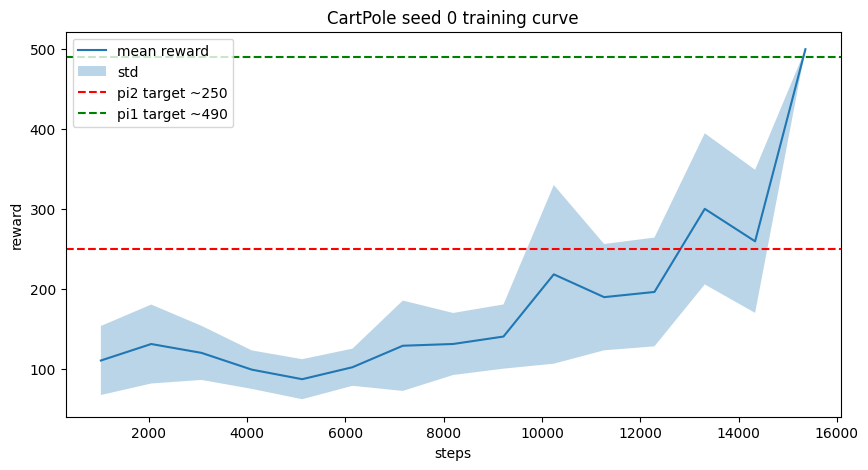


Done! Saved policies:
  pi1_cartpole_seed0.zip  |  pi2_cartpole_seed0.zip


In [2]:
import os
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.vec_env import DummyVecEnv

save_path = "outputs/checkpoints"
os.makedirs(save_path, exist_ok=True)

target_pi2_reward = 250
target_pi1_reward = 490
seed = 0
pi2_steps = 14336

checkpoint_interval = 1024

def make_env(env_id: str, seed: int) -> gym.Env:
    env = gym.make(env_id)
    env.reset(seed=seed)
    return env

print(f"\n=== CartPole seed {seed} ===")

rng = np.random.default_rng(seed)
env_train = DummyVecEnv([lambda: make_env("CartPole-v1", seed=int(rng.integers(0, 1000000)))])
n_eval_episodes = 20
env_eval  = DummyVecEnv([lambda: make_env("CartPole-v1", seed=int(rng.integers(0, 1000000))) for _ in range(n_eval_episodes)])

steps_log, mean_log, std_log = [], [], []

model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    device="cpu",
    seed=seed,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=5,
    ent_coef=0.01,
    gamma=0.99,
)

total_steps = 0
pi2_saved = False
pi1_saved = False

for _ in range(0, 100_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model, env_eval, n_eval_episodes=n_eval_episodes, deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    # save pi2 at target steps
    if total_steps == pi2_steps and not pi2_saved:
        model.save(os.path.join(save_path, f"pi2_cartpole_seed{seed}"))
        print(f">>> pi2 saved at {total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")
        pi2_saved = True

    # save pi1 once policy is excellent
    if mean_reward >= target_pi1_reward and not pi1_saved:
        model.save(os.path.join(save_path, f"pi1_cartpole_seed{seed}"))
        print(f">>> pi1 saved at {total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")
        pi1_saved = True

    if pi1_saved:
        print(f"Both policies saved for seed {seed}, stopping")
        break

# pick the best checkpoint for pi2 on the next run
if steps_log:
    mean_array = np.asarray(mean_log)
    best_pi2_idx = int(np.argmin(np.abs(mean_array - target_pi2_reward)))
    best_pi2_steps = steps_log[best_pi2_idx]
    best_pi2_reward = mean_log[best_pi2_idx]
    print(
        f"Suggested pi2_steps for the next run: {best_pi2_steps} "
        f"(mean reward {best_pi2_reward:.1f}, target {target_pi2_reward})"
    )
    pi2_steps = best_pi2_steps

# plot
plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(
    steps_log,
    [m - s for m, s in zip(mean_log, std_log)],
    [m + s for m, s in zip(mean_log, std_log)],
    alpha=0.3, label="std"
)
plt.axhline(target_pi2_reward, color="red",   linestyle="--", label=f"pi2 target ~{target_pi2_reward}")
plt.axhline(target_pi1_reward, color="green", linestyle="--", label=f"pi1 target ~{target_pi1_reward}")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title(f"CartPole seed {seed} training curve")
plt.legend()
plt.show()

print("\nDone! Saved policies:")
print(f"  pi1_cartpole_seed{seed}.zip  |  pi2_cartpole_seed{seed}.zip")


=== Pendulum seed 0 ===
16384 steps: -1131.2 +/- 234.5
32768 steps: -1130.7 +/- 353.9
49152 steps: -1200.2 +/- 280.2
65536 steps: -1244.5 +/- 273.5
81920 steps: -1170.0 +/- 254.0
98304 steps: -1179.3 +/- 254.3
114688 steps: -1000.2 +/- 226.2
131072 steps: -1074.7 +/- 190.4
147456 steps: -1043.2 +/- 150.8
163840 steps: -1018.6 +/- 235.0
180224 steps: -950.5 +/- 220.0
196608 steps: -887.3 +/- 175.7
212992 steps: -953.3 +/- 202.2
229376 steps: -973.8 +/- 126.2
245760 steps: -898.9 +/- 312.6
262144 steps: -983.2 +/- 218.5
278528 steps: -976.9 +/- 125.4
294912 steps: -1003.9 +/- 163.0
311296 steps: -874.8 +/- 233.7
327680 steps: -848.0 +/- 253.6
>>> pi2 saved at 327680 steps: -848.0 +/- 253.6
344064 steps: -686.0 +/- 268.1
360448 steps: -489.5 +/- 337.9
376832 steps: -339.7 +/- 212.2
393216 steps: -211.9 +/- 148.8
409600 steps: -172.5 +/- 145.5
>>> pi1 saved at 409600 steps: -172.5 +/- 145.5
Both policies saved for seed 0, stopping
Suggested pi2_steps for the next run: 245760 (mean reward 

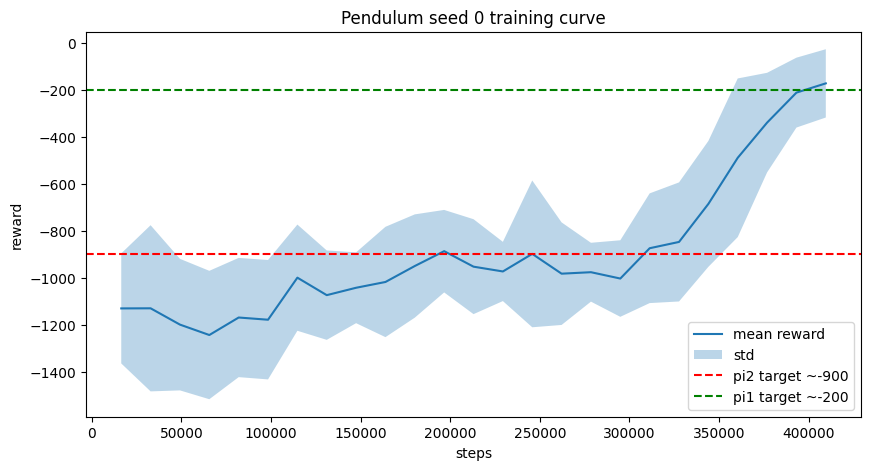


Done! Saved policies:
  pi1_pendulum_seed0.zip  |  pi2_pendulum_seed0.zip


In [6]:
target_pi2_reward = -900
target_pi1_reward = -200
checkpoint_interval = 1024 * 16

seed = 0
pi2_steps = 327680

print(f"\n=== Pendulum seed {seed} ===")

rng = np.random.default_rng(seed)
env_train = DummyVecEnv([lambda: make_env("Pendulum-v1", seed=int(rng.integers(0, 1000000)))])
n_eval_episodes = 20
env_eval  = DummyVecEnv([lambda: make_env("Pendulum-v1", seed=int(rng.integers(0, 1000000))) for _ in range(n_eval_episodes)])

steps_log, mean_log, std_log = [], [], []

model = PPO(
    "MlpPolicy", env_train, verbose=0, device="cpu", seed=seed,
    learning_rate=3e-4, n_steps=2048, batch_size=64,
    n_epochs=5, ent_coef=0.01, gamma=0.99,
)

total_steps = 0
pi2_saved = False
pi1_saved = False

for _ in range(0, 1_000_000, checkpoint_interval):
    model.learn(
        total_timesteps=checkpoint_interval,
        reset_num_timesteps=False
    )
    total_steps += checkpoint_interval
    mean_reward, std_reward = evaluate_policy(
        model, env_eval, n_eval_episodes=n_eval_episodes, deterministic=True
    )
    steps_log.append(total_steps)
    mean_log.append(mean_reward)
    std_log.append(std_reward)
    print(f"{total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")

    # save pi2 at target steps
    if total_steps == pi2_steps and not pi2_saved:
        model.save(os.path.join(save_path, f"pi2_pendulum_seed{seed}"))
        print(f">>> pi2 saved at {total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")
        pi2_saved = True

    # save pi1 once policy is excellent
    if mean_reward >= target_pi1_reward and not pi1_saved:
        model.save(os.path.join(save_path, f"pi1_pendulum_seed{seed}"))
        print(f">>> pi1 saved at {total_steps} steps: {mean_reward:.1f} +/- {std_reward:.1f}")
        pi1_saved = True

    if pi1_saved:
        print(f"Both policies saved for seed {seed}, stopping")
        break

# pick the best checkpoint for pi2 on the next run
if steps_log:
    mean_array = np.asarray(mean_log)
    best_pi2_idx = int(np.argmin(np.abs(mean_array - target_pi2_reward)))
    best_pi2_steps = steps_log[best_pi2_idx]
    best_pi2_reward = mean_log[best_pi2_idx]
    print(
        f"Suggested pi2_steps for the next run: {best_pi2_steps} "
        f"(mean reward {best_pi2_reward:.1f}, target {target_pi2_reward})"
    )
    pi2_steps = best_pi2_steps

# plot
plt.figure(figsize=(10, 5))
plt.plot(steps_log, mean_log, label="mean reward")
plt.fill_between(
    steps_log,
    [m - s for m, s in zip(mean_log, std_log)],
    [m + s for m, s in zip(mean_log, std_log)],
    alpha=0.3, label="std"
)
plt.axhline(target_pi2_reward, color="red",   linestyle="--", label=f"pi2 target ~{target_pi2_reward}")
plt.axhline(target_pi1_reward, color="green", linestyle="--", label=f"pi1 target ~{target_pi1_reward}")
plt.xlabel("steps")
plt.ylabel("reward")
plt.title(f"Pendulum seed {seed} training curve")
plt.legend()
plt.show()

print("\nDone! Saved policies:")
print(f"  pi1_pendulum_seed{seed}.zip  |  pi2_pendulum_seed{seed}.zip")